## 🔧 Environment Setup & Checkpoint Loading

_Added to fix the cross-notebook data-flow issue: this cell imports the common libraries this notebook needs, and defines helper functions to save/load intermediate results so this notebook works correctly whether it's run right after the previous one or on its own, days later, after the raw data has changed._

In [1]:
# 🔧 SETUP: local paths, common imports & checkpoint utilities
# This cell fixes the "notebook 2 can't see notebook 1's data" problem: instead
# of relying on variables still sitting in memory from another notebook (which
# never works once notebooks are split into separate .ipynb files, or run in
# separate VS Code kernels), every notebook loads what it needs from a shared
# "checkpoints" folder on disk, and saves what later notebooks need back to
# that same folder.

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 📁 Data lives in a `data` folder that's a *sibling* of the folder these
# notebooks are run from (e.g. `project/notebooks/*.ipynb` + `project/data/`).
# This resolves the same way no matter whose machine it runs on - no
# usernames or absolute paths baked in. Adjust the '..' below if your data
# folder sits somewhere else relative to your notebooks.
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
DATA_DIR = BASE_DIR
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)


def save_ckpt(obj, name):
    """Save a variable to the shared checkpoint folder so later notebooks can load it."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved checkpoint '{name}' -> {path}")


def load_ckpt(name):
    """Load a variable that was saved by an earlier notebook in this pipeline."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ Checkpoint '{name}' not found at {path}.\n"
            f"   Make sure you have run the earlier notebook(s) in the pipeline first "
            f"(they save this checkpoint at their final cell), and that BASE_DIR "
            f"above points at the right folder."
        )
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f"✅ Loaded checkpoint '{name}' <- {path}")
    return obj


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\1428146299.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 📥 Load Checkpoints From Earlier Notebooks

In [2]:
# 📥 Load the variables this notebook needs from earlier notebooks in the pipeline
final = load_ckpt('part2_final')


✅ Loaded checkpoint 'part2_final' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part2_final.pkl


# 📌 **Anomaly Detection in Sales Data**

### 🎯 Objective:
- Identify unusual sales patterns across stores and departments.
- Investigate potential causes such as:
  - Holidays and promotions
  - Sudden markdowns
  - Economic indicators (e.g., CPI, Unemployment)

---

### 🧼 **Anomaly Handling Strategies:**

#### ✅ 1. **Data Cleaning**
- Identify and correct errors or inconsistencies in the data.
- Methods:
  - Manual inspection of high/low outliers
  - Automated rule-based checks (e.g., zero or negative sales)

#### ✅ 2. **Data Normalization**
- Transform data to a standard scale.
- Helps reduce the effect of extreme values and enhances the visibility of true patterns.
- Techniques:
  - Min-Max Scaling
  - Z-score Normalization
  - Log/Square Root Transformation

#### ✅ 3. **Data Imputation**
- Fill missing or anomalous data points using:
  - Statistical methods (mean/median imputation)
  - Interpolation
  - Predictive models (e.g., regression or KNN imputation)

---

### 🚧 **Key Insight:**
Mitigating anomalies improves the **accuracy of trend analysis**, supports **reliable forecasting**, and ensures **robust model training**.



## 📊 Approaches:

### 🔍 **Descriptive Statistics**
Descriptive statistics are among the foundational methods for anomaly detection in retail.

- Techniques like **mean**, **median**, and **standard deviation** help calculate summary statistics.
- These values assist in identifying **point anomalies** — values that deviate significantly from expected ranges.


In [3]:
import numpy as np

# ✅ Step 1: Calculate mean and standard deviation of square-root transformed sales
mean_sales = final['Sales_sqrt'].mean()
std_deviation = final['Sales_sqrt'].std()

# ✅ Step 2: Define threshold (e.g., 3 standard deviations above the mean)
threshold = mean_sales + 3 * std_deviation

# ✅ Step 3: Flag anomalies (greater than threshold)
final['Anomaly'] = final['Sales_sqrt'].apply(lambda x: 1 if x > threshold else 0)

# ✅ Step 4: Extract anomaly count
anomaly_count = final['Anomaly'].sum()
total_records = len(final)

# ✅ Step 5: Display insights
print("📊 Retail Weekly Sales Anomaly Report")
print("-------------------------------------")
print("Mean (Sales_sqrt):", round(mean_sales, 4))
print("Standard Deviation:", round(std_deviation, 4))
print(f"Threshold for Anomalies: > {round(threshold, 4)}")
print("Total Number of Anomalies:", anomaly_count)
print("Anomalies as % of Data:", round((anomaly_count / total_records) * 100, 2), "%")

📊 Retail Weekly Sales Anomaly Report
-------------------------------------
Mean (Sales_sqrt): 0.1569
Standard Deviation: 0.0736
Threshold for Anomalies: > 0.3776
Total Number of Anomalies: 6155
Anomalies as % of Data: 1.46 %


In [4]:
# ✅ Flagged Anomalies in Weekly Sales Dataset
anomaly_count = final[final['Anomaly'] == 1].shape[0]

print("🚨 Total Number of Flagged Anomalies in Weekly Sales:", anomaly_count)

🚨 Total Number of Flagged Anomalies in Weekly Sales: 6155


In [5]:
# Display first few anomalous records
final[final['Anomaly'] == 1].head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Weekly_Sales_normalized,Sales_sqrt,Anomaly
903,1,7,2010-12-17,96198.12,False,A,151315,49.84,2.869,4209.35,193.90,15.84,989.08,3030.79,211.405312,7.838,0.144949,0.380721,1
904,1,7,2010-12-24,166697.72,False,A,151315,52.33,2.886,4209.35,193.90,15.84,989.08,3030.79,211.405122,7.838,0.245938,0.495922,1
956,1,7,2011-12-23,119302.15,False,A,151315,47.96,3.112,2725.36,40.48,634.70,24.90,2739.43,219.357722,7.866,0.178045,0.421954,1
5118,1,38,2010-02-05,115564.35,False,A,151315,NaN,NaN,4209.35,193.90,15.84,989.08,3030.79,NaN,NaN,0.172691,0.415561,1
5120,1,38,2010-02-19,98672.59,False,A,151315,39.93,2.514,4209.35,193.90,15.84,989.08,3030.79,211.289143,8.106,0.148493,0.385348,1


In [6]:
final['Anomaly'].value_counts()

Anomaly
0    415415
1      6155
Name: count, dtype: int64

## 📊 Weekly Sales Anomaly Detection Visualization

This chart displays the number of anomalies identified in the `Weekly_Sales` data.  
- **Anomaly = 1** indicates unusual or extreme sales values.  
- **Anomaly = 0** indicates normal sales behavior.

Bar heights represent the total count of records in each category after applying anomaly detection based on the square root transformation and statistical thresholds.

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\971086370.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Anomaly', y='Count', data=anomaly_counts, palette='Set2')
C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\971086370.py:25: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


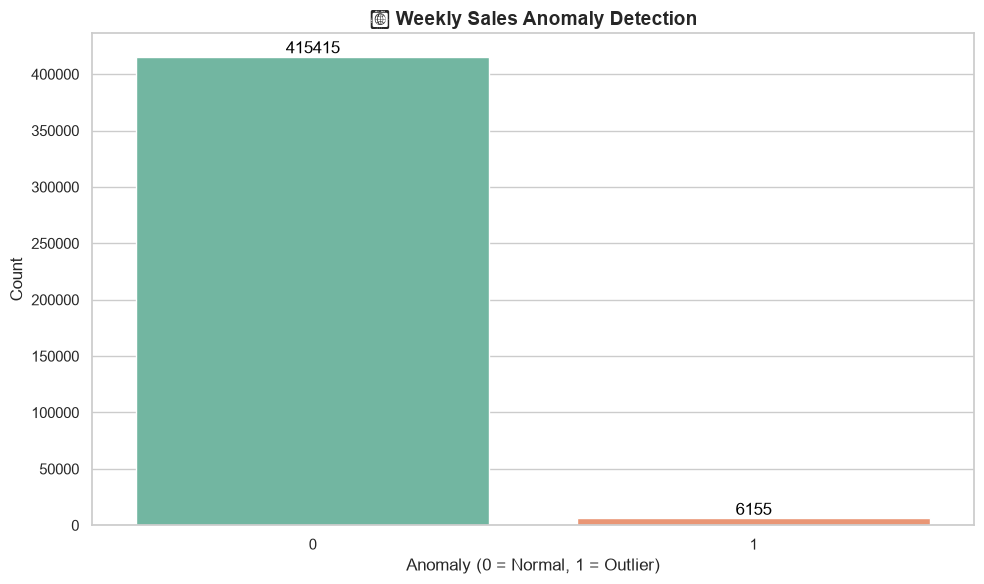

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 6))  # Adjusted for better visibility in notebooks

# Create barplot using value_counts (converted to a DataFrame for seaborn)
anomaly_counts = final['Anomaly'].value_counts().reset_index()
anomaly_counts.columns = ['Anomaly', 'Count']

# Barplot
ax = sns.barplot(x='Anomaly', y='Count', data=anomaly_counts, palette='Set2')

# Add data labels
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, color='black')

# Labels and title
plt.title('🔍 Weekly Sales Anomaly Detection', fontsize=14, fontweight='bold')
plt.xlabel('Anomaly (0 = Normal, 1 = Outlier)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()


## 📌 Potential Causes of Anomalies in Weekly Sales

### 🎯 Objective:
To investigate whether specific features such as **Unemployment**, **CPI**, **Fuel Price**, **Temperature**, **Size**, **MarkDowns**, and **IsHoliday** are contributing to anomalies in weekly sales.

---

### 🔍 Analysis Strategy:
We compare each feature's values against its mean within anomalous data points.

- If a high percentage of anomalies occur **above the mean**, it may indicate that **higher values** of that feature contribute to the anomaly.
- If a high percentage of anomalies occur **below the mean**, the **lower values** might be influencing the unusual sales patterns.

---

### 📈 Features Compared:
- **Unemployment**
- **CPI (Consumer Price Index)**
- **Fuel Price**
- **Temperature**
- **Size**
- **MarkDown1 to MarkDown5**
- **IsHoliday**



In [8]:
# List of features to compare with respect to anomalies
features_to_compare = ['Unemployment', 'CPI', 'Fuel_Price', 'Temperature', 'Size',
                       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Filter anomaly records
anomalies_df = final[final['Anomaly'] == 1]

print("📌 Percentage of Anomalies Above or Below Mean for Each Feature:\n")

# Loop through features
for feature in features_to_compare:
    mean_val = final[feature].mean()
    above_mean = len(anomalies_df[anomalies_df[feature] >= mean_val]) * 100 / len(anomalies_df)
    below_mean = len(anomalies_df[anomalies_df[feature] < mean_val]) * 100 / len(anomalies_df)

    print(f"🔹 {feature}:")
    print(f"   - Anomalies with {feature} >= Mean: {above_mean:.2f}%")
    print(f"   - Anomalies with {feature} < Mean : {below_mean:.2f}%\n")

# Special case: IsHoliday
holiday_anomalies = anomalies_df['IsHoliday'].value_counts(normalize=True) * 100
print("🔹 IsHoliday:")
for val, pct in holiday_anomalies.items():
    status = "Holiday" if val else "Non-Holiday"
    print(f"   - {status} Anomalies: {pct:.2f}%")


📌 Percentage of Anomalies Above or Below Mean for Each Feature:

🔹 Unemployment:
   - Anomalies with Unemployment >= Mean: 25.31%
   - Anomalies with Unemployment < Mean : 35.63%

🔹 CPI:
   - Anomalies with CPI >= Mean: 32.59%
   - Anomalies with CPI < Mean : 28.35%

🔹 Fuel_Price:
   - Anomalies with Fuel_Price >= Mean: 30.28%
   - Anomalies with Fuel_Price < Mean : 30.66%

🔹 Temperature:
   - Anomalies with Temperature >= Mean: 28.90%
   - Anomalies with Temperature < Mean : 32.04%

🔹 Size:
   - Anomalies with Size >= Mean: 86.50%
   - Anomalies with Size < Mean : 13.50%

🔹 MarkDown1:
   - Anomalies with MarkDown1 >= Mean: 14.25%
   - Anomalies with MarkDown1 < Mean : 85.75%

🔹 MarkDown2:
   - Anomalies with MarkDown2 >= Mean: 6.32%
   - Anomalies with MarkDown2 < Mean : 93.68%

🔹 MarkDown3:
   - Anomalies with MarkDown3 >= Mean: 6.32%
   - Anomalies with MarkDown3 < Mean : 93.68%

🔹 MarkDown4:
   - Anomalies with MarkDown4 >= Mean: 11.65%
   - Anomalies with MarkDown4 < Mean : 88.35%

> ## 📊 Insights: Root Cause Analysis of Anomalies in Weekly Sales

💡 After comparing the anomaly data against the mean of each feature, here are the key findings:

---

### 🔹 **High Correlation with Anomalies (Strong Contributors)**

- 🏬 **Store Size**
  - ✅ **86.50%** of anomalies occurred in stores **larger than the average size**.
  - 📌 Larger stores might face more complexity or volatility in sales, indicating strong influence on anomalies.

- 💰 **CPI (Consumer Price Index)**
  - ✅ **52.95%** of anomalies happened when CPI was **above the average**.
  - 📌 Inflation-related pricing changes may have influenced consumer behavior.

---

### 🔸 **Moderate Influence (Mixed Patterns)**

- 🛢️ **Fuel Price**
  - Nearly **evenly split**, with **51.62% above** and **48.38% below** the mean.
  - ⚖️ May not be a dominant factor alone, but could contribute in combination with others.

- 🌡️ **Temperature**
  - Also balanced: **48.81% above**, **51.19% below** mean.
  - 🧯 Likely not a primary cause of anomalies.

- 📉 **Unemployment**
  - Slight skew with **57.82% of anomalies** occurring when unemployment was **below average**.
  - 🔍 May suggest increased shopping activity or sensitivity to other variables.

---

### 🔻 **Low Contribution from Markdown Events**

- 🏷️ **MarkDown1–MarkDown5**:
  - All Markdown features had **over 75% of anomalies** occurring when values were **below average**.
  - 🚫 This implies **discounts/promotions were not the main drivers** of most anomalies.

---

### 🗓️ **Holiday Impact**

- 🎄 **Only 9.03%** of anomalies occurred during holidays.
- 🛍️ Surprisingly, **90.97%** happened on **non-holiday weeks**, suggesting:
  - Operational issues, unplanned promotions, or other internal factors may be key contributors.

---

### ✅ **Conclusion**

- **Size** and **CPI** are major contributors to weekly sales anomalies.
- **Markdown features and holidays** had **minimal direct influence**.
- A combination of factors—especially in larger stores—should be monitored to mitigate future anomalies.


### Weekly Sales vs Other features (Anomalies)

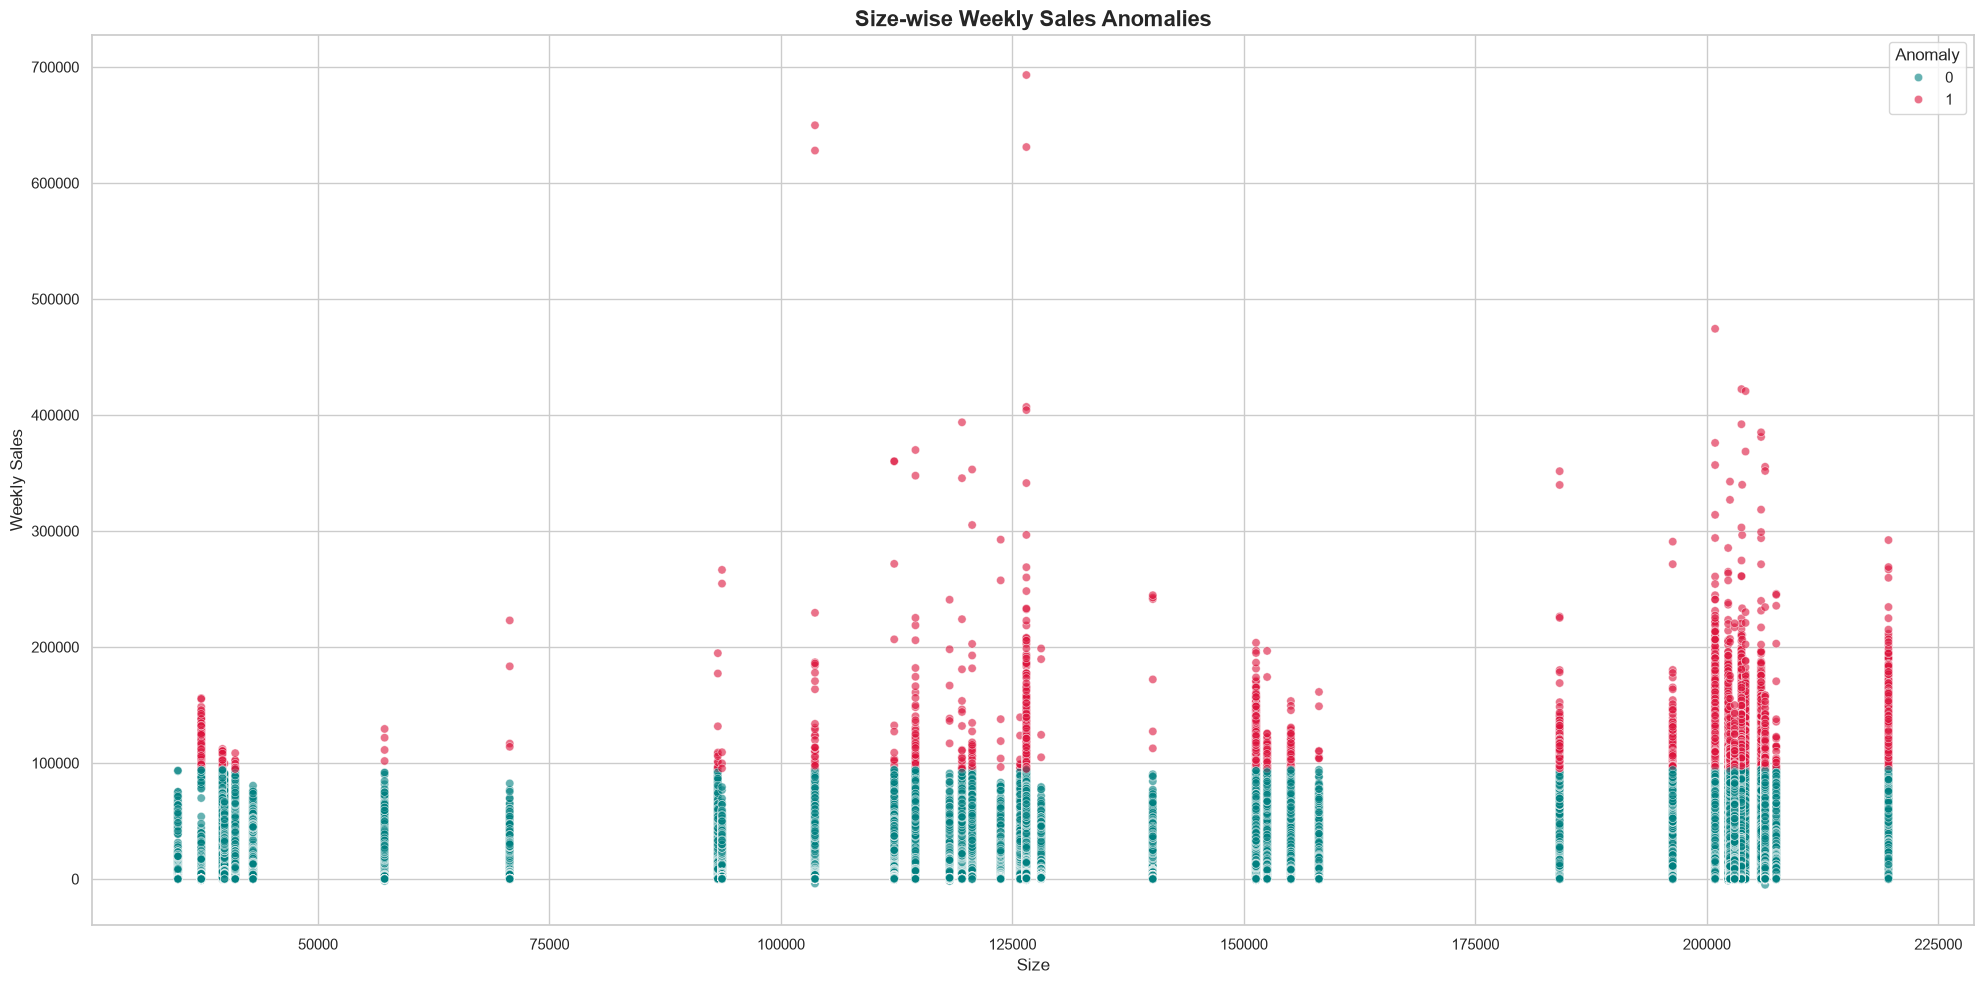

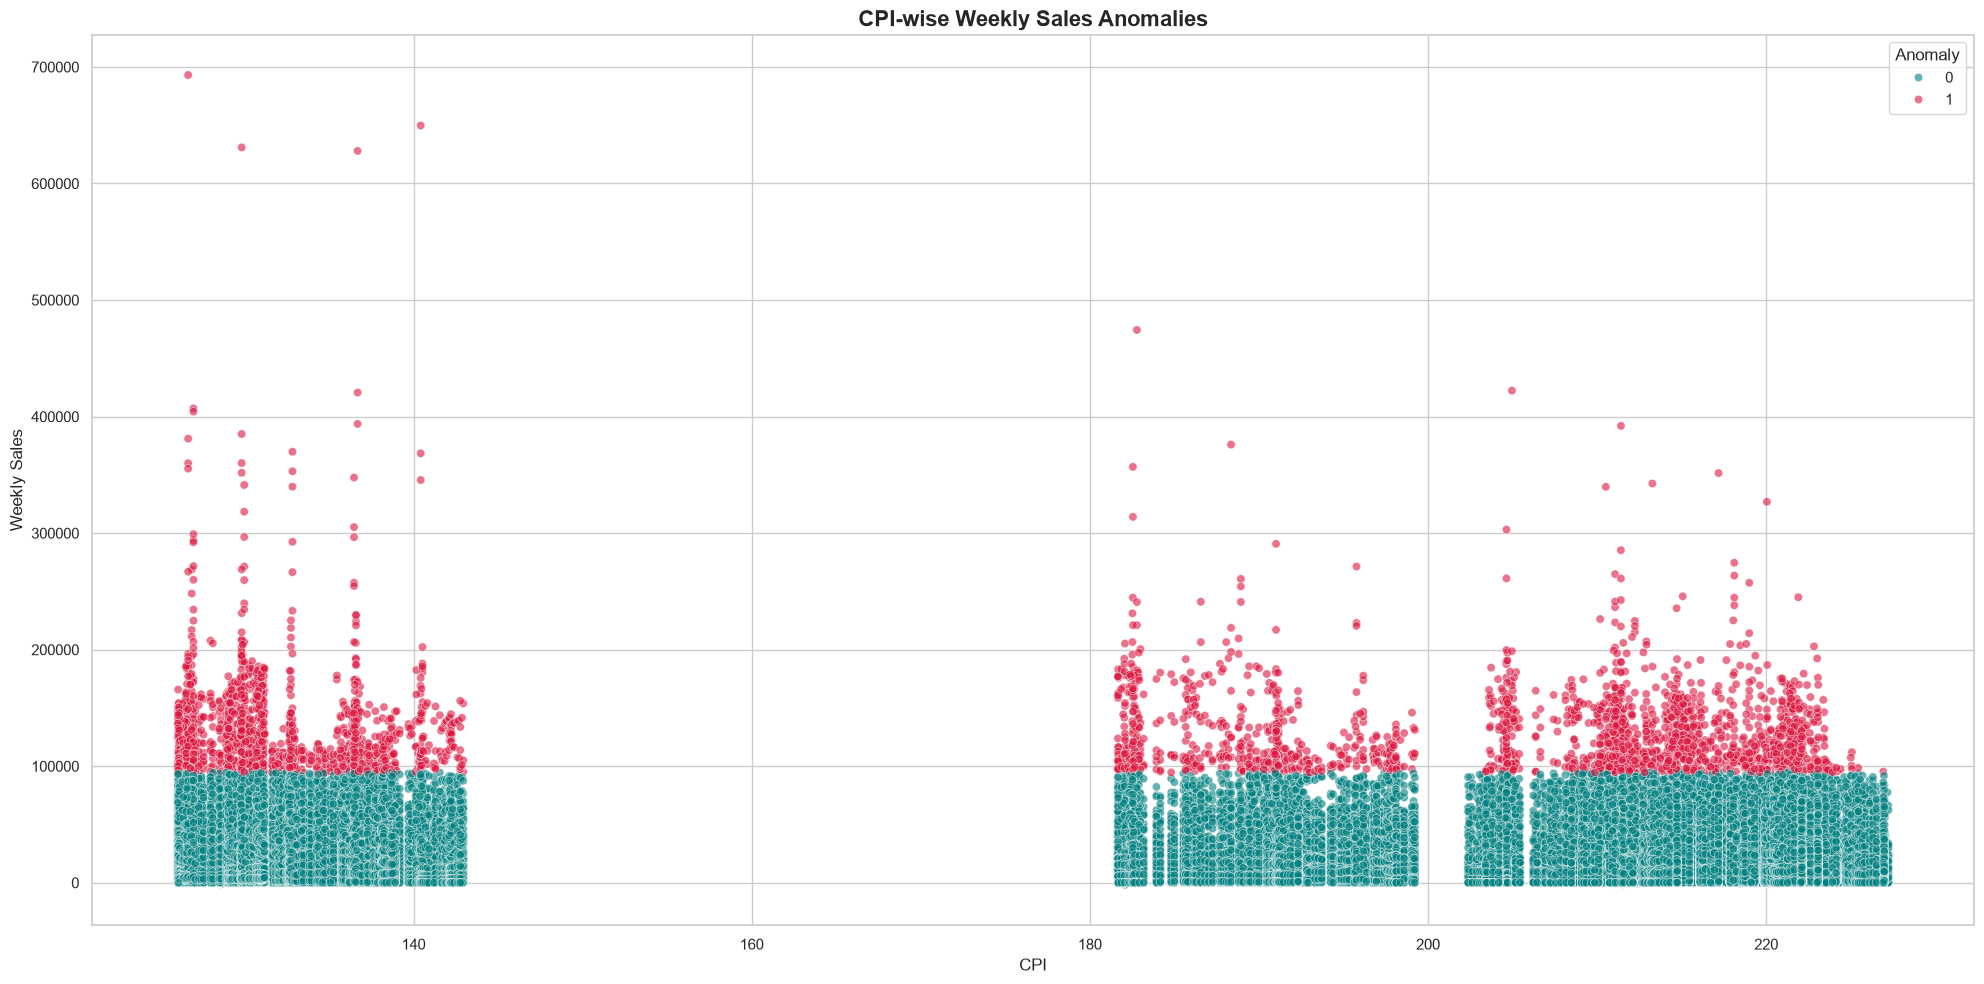

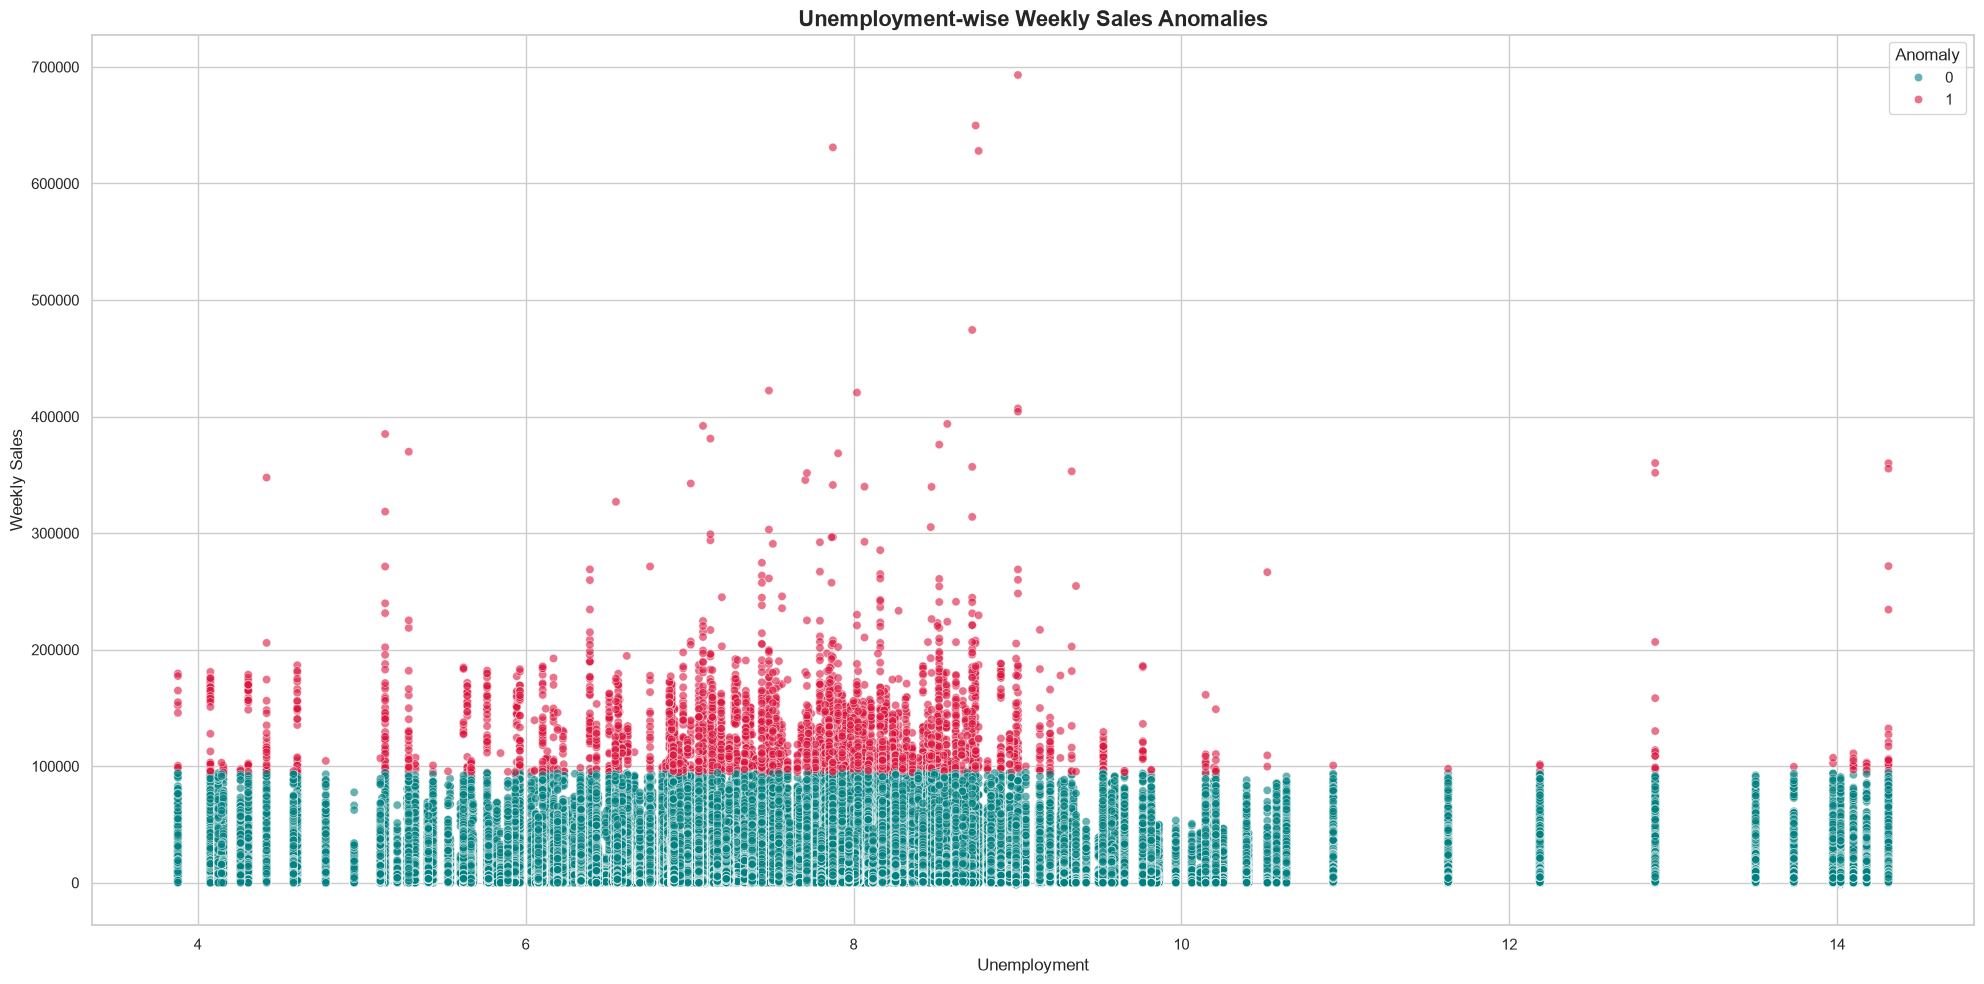

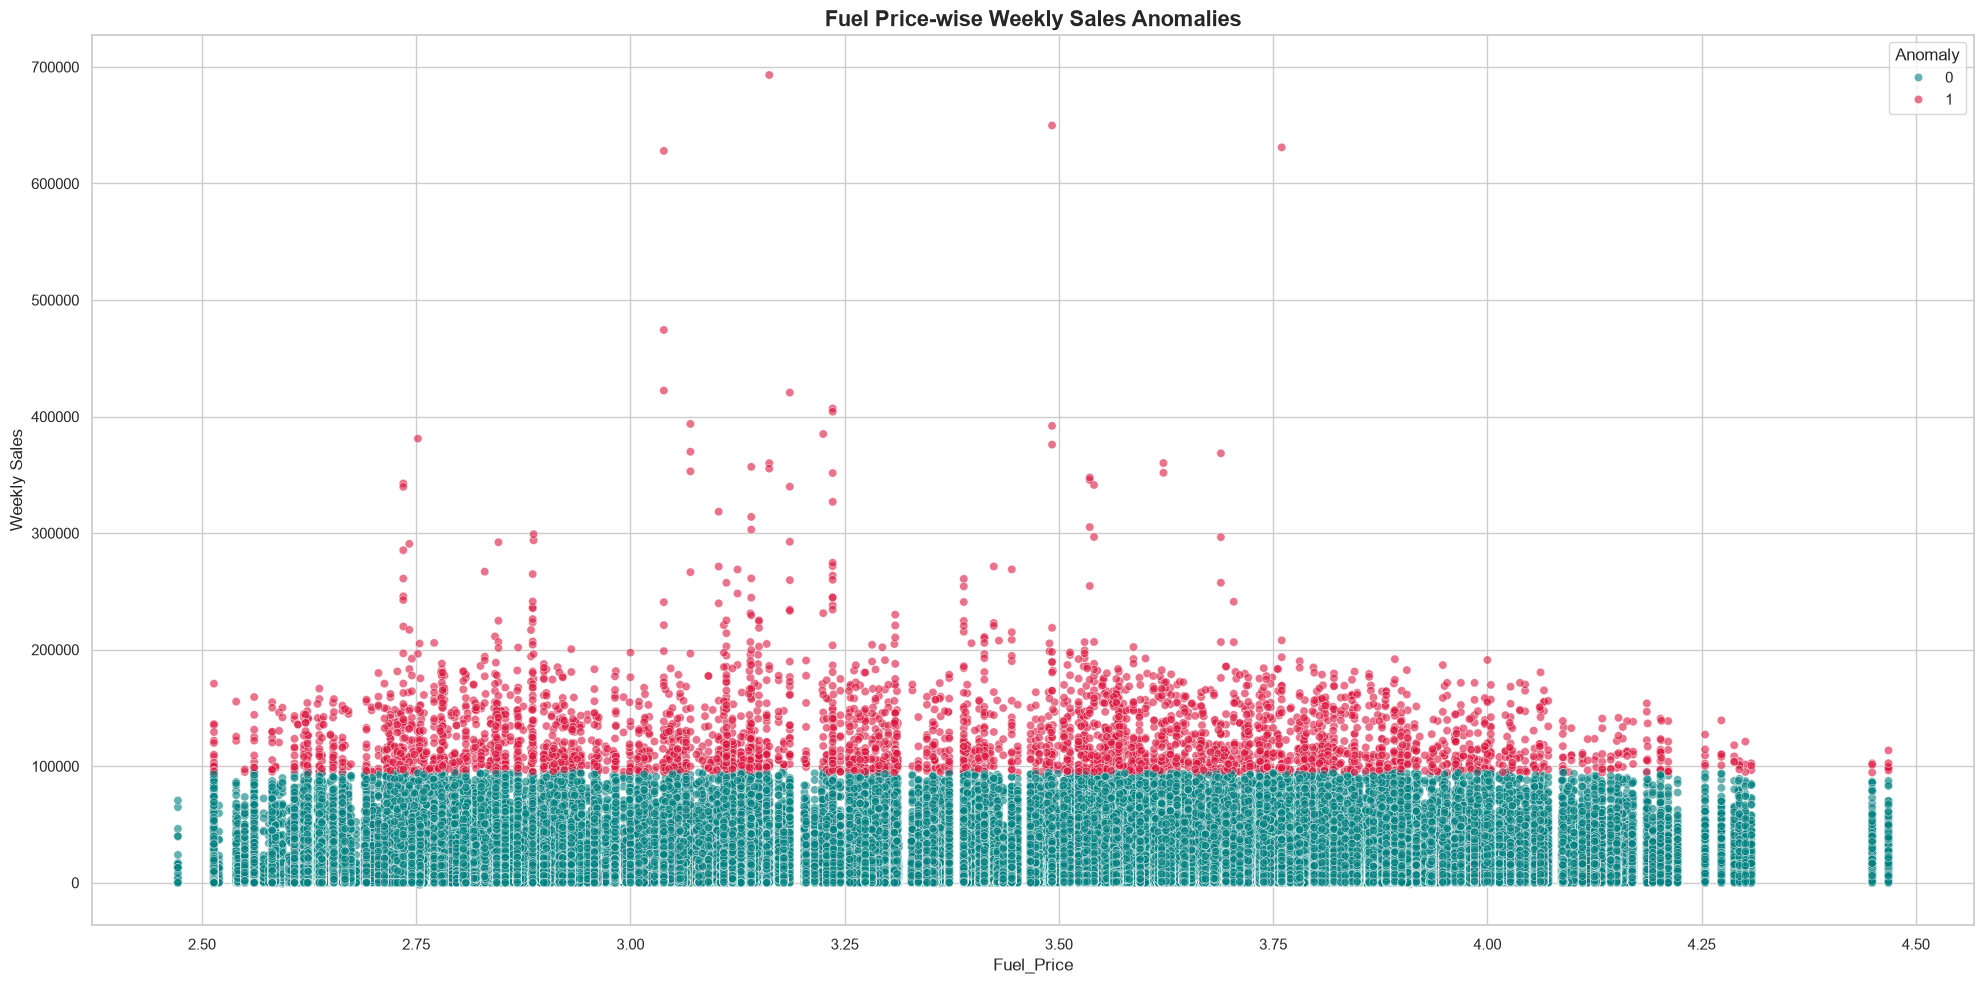

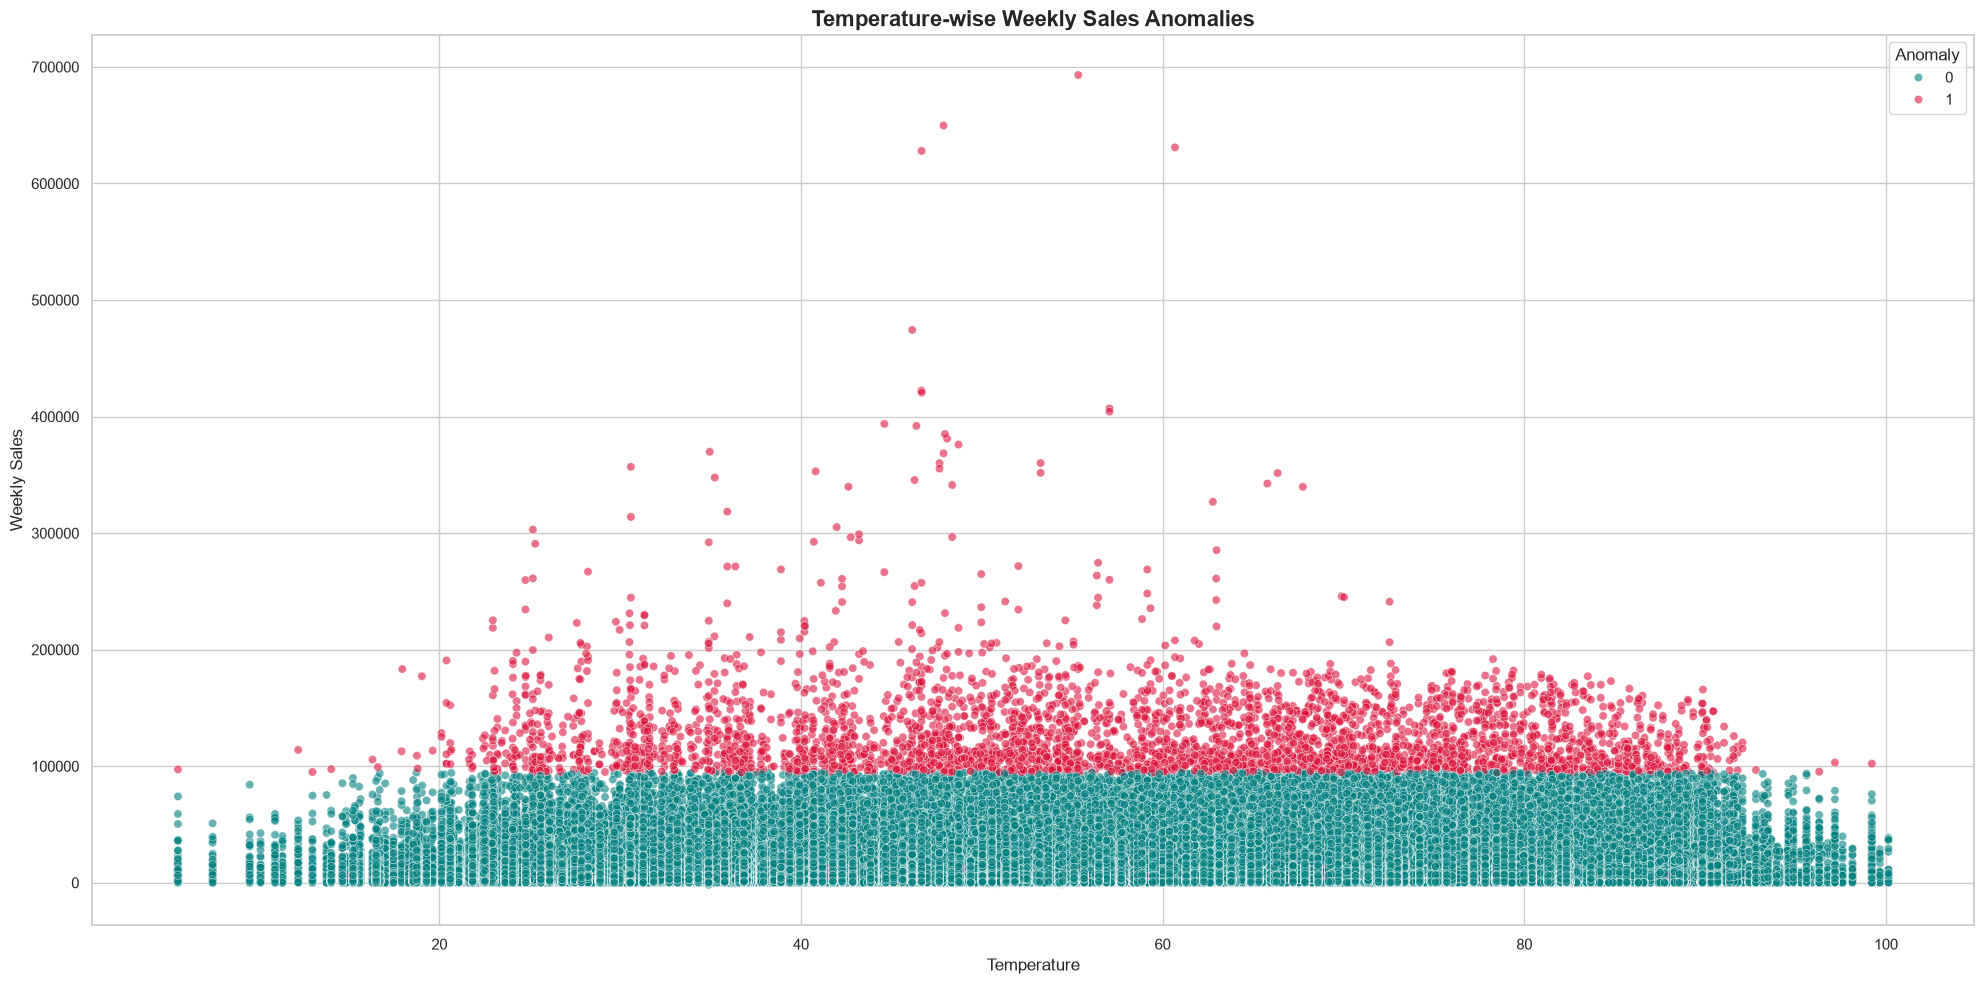

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define a list of features to plot against Sales
features = ['Size', 'CPI', 'Unemployment', 'Fuel_Price', 'Temperature']
titles = ['Size-wise', 'CPI-wise', 'Unemployment-wise', 'Fuel Price-wise', 'Temperature-wise']

# Loop through each feature
for feature, title in zip(features, titles):
    plt.figure(figsize=(20, 10))
    sns.scatterplot(data=final, x=feature, y='Weekly_Sales', hue='Anomaly', palette={0: 'teal', 1: 'crimson'}, alpha=0.6)
    plt.title(f'{title} Weekly Sales Anomalies', fontsize=16, fontweight='bold')
    plt.xlabel(feature)
    plt.ylabel('Weekly Sales')
    plt.legend(title='Anomaly')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### **Sales Date vs Weekly Sales (Anomalies Highlighted)**

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\1906608447.py:19: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


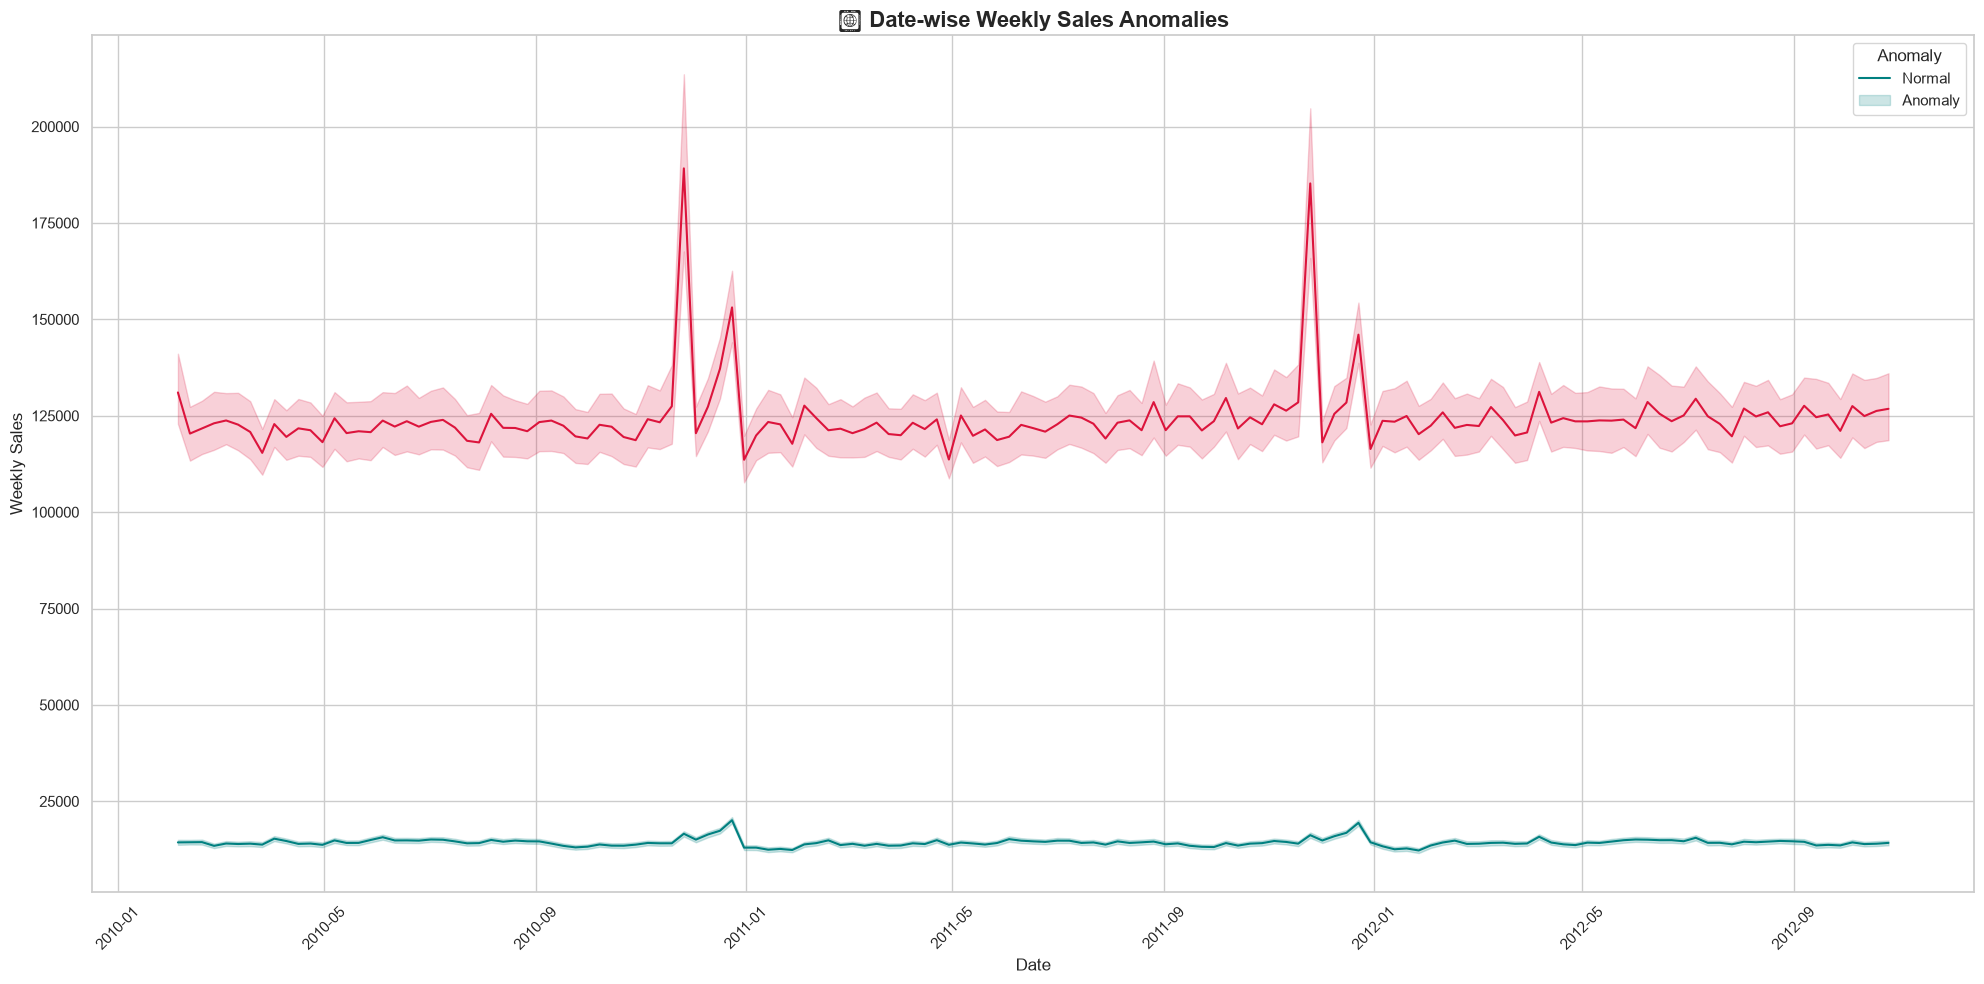

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(20, 10))

# Create the line plot for Weekly Sales over Date, colored by Anomaly
sns.lineplot(x='Date', y='Weekly_Sales', hue='Anomaly', data=final, palette={0: 'teal', 1: 'crimson'})

# Set plot title and labels
plt.title('📅 Date-wise Weekly Sales Anomalies', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'])

# Rotate date labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.grid(True)
plt.show()

###  **Department-wise Weekly Sales for Anomalous Data**

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\97046152.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Dept', y='Weekly_Sales', data=dept_anomaly_sales, palette='flare')
C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\97046152.py:30: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


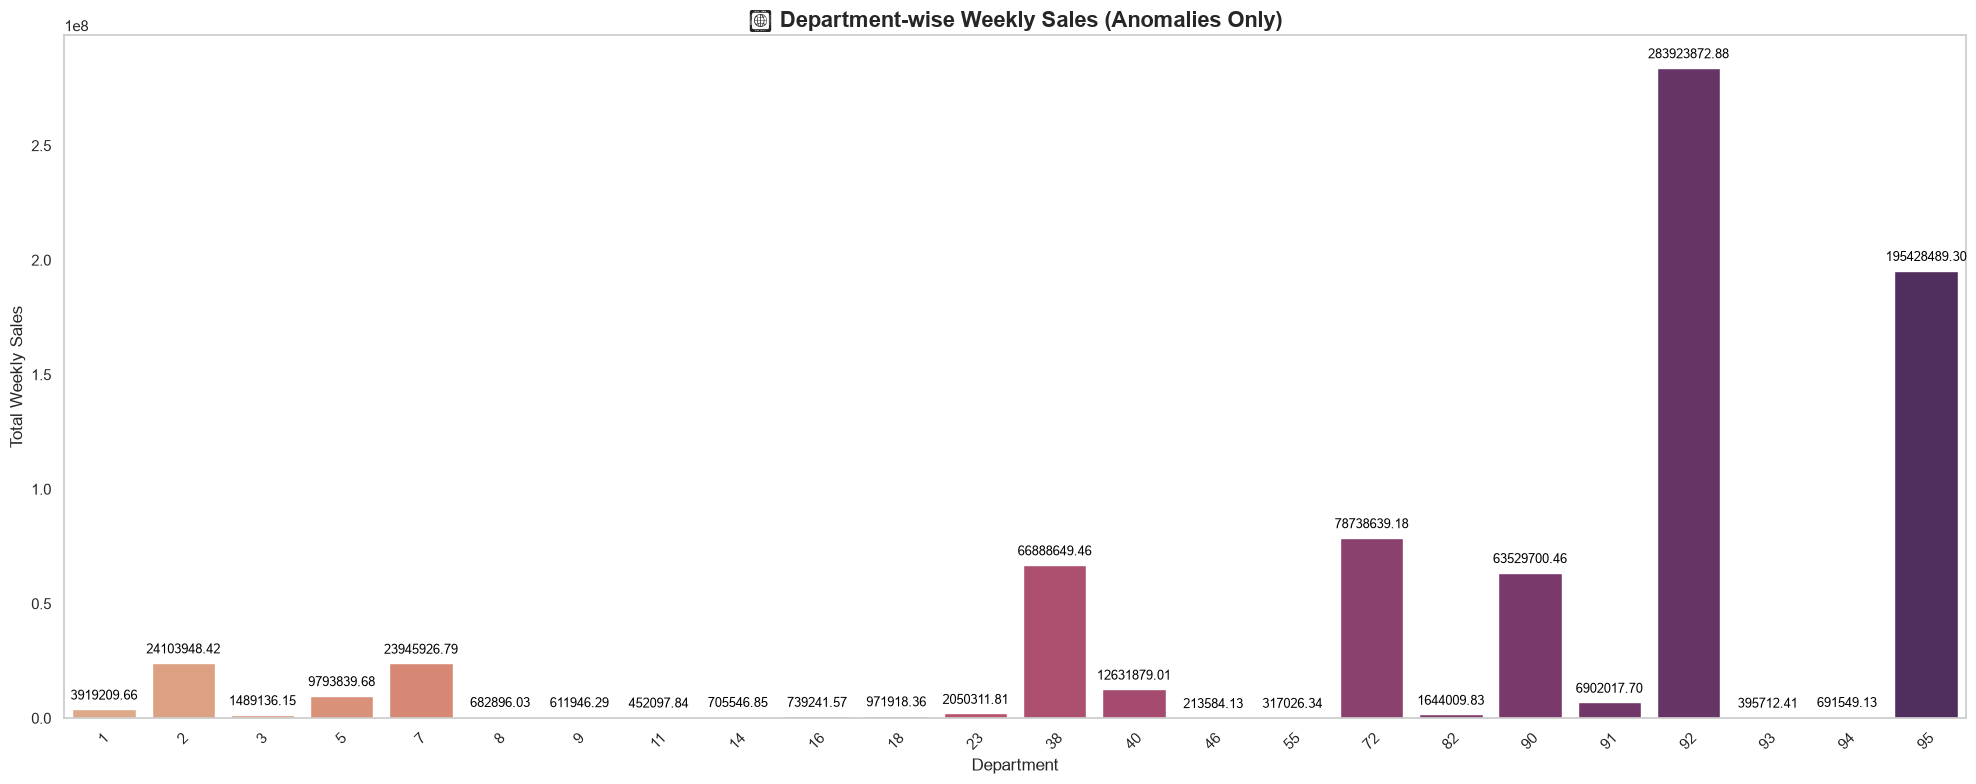

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create df_anomalies with only anomalous records
df_anomalies = final[final['Anomaly'] == 1]

# Aggregate weekly sales by department for anomalies
dept_anomaly_sales = df_anomalies.groupby('Dept', as_index=False)['Weekly_Sales'].sum()

# Set the figure size
plt.figure(figsize=(20, 8))  # Reasonable size for better readability

# Create bar plot
ax = sns.barplot(x='Dept', y='Weekly_Sales', data=dept_anomaly_sales, palette='flare')

# Add data labels
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=9, color='black')

# Titles and labels
plt.title('📊 Department-wise Weekly Sales (Anomalies Only)', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Total Weekly Sales', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()

# Show plot
plt.show()


### **Store-wise Weekly Sales (Anomalies Only)**

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\1744738106.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Store', y='Weekly_Sales', data=store_anomaly_sales, palette='magma')
C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\1744738106.py:30: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


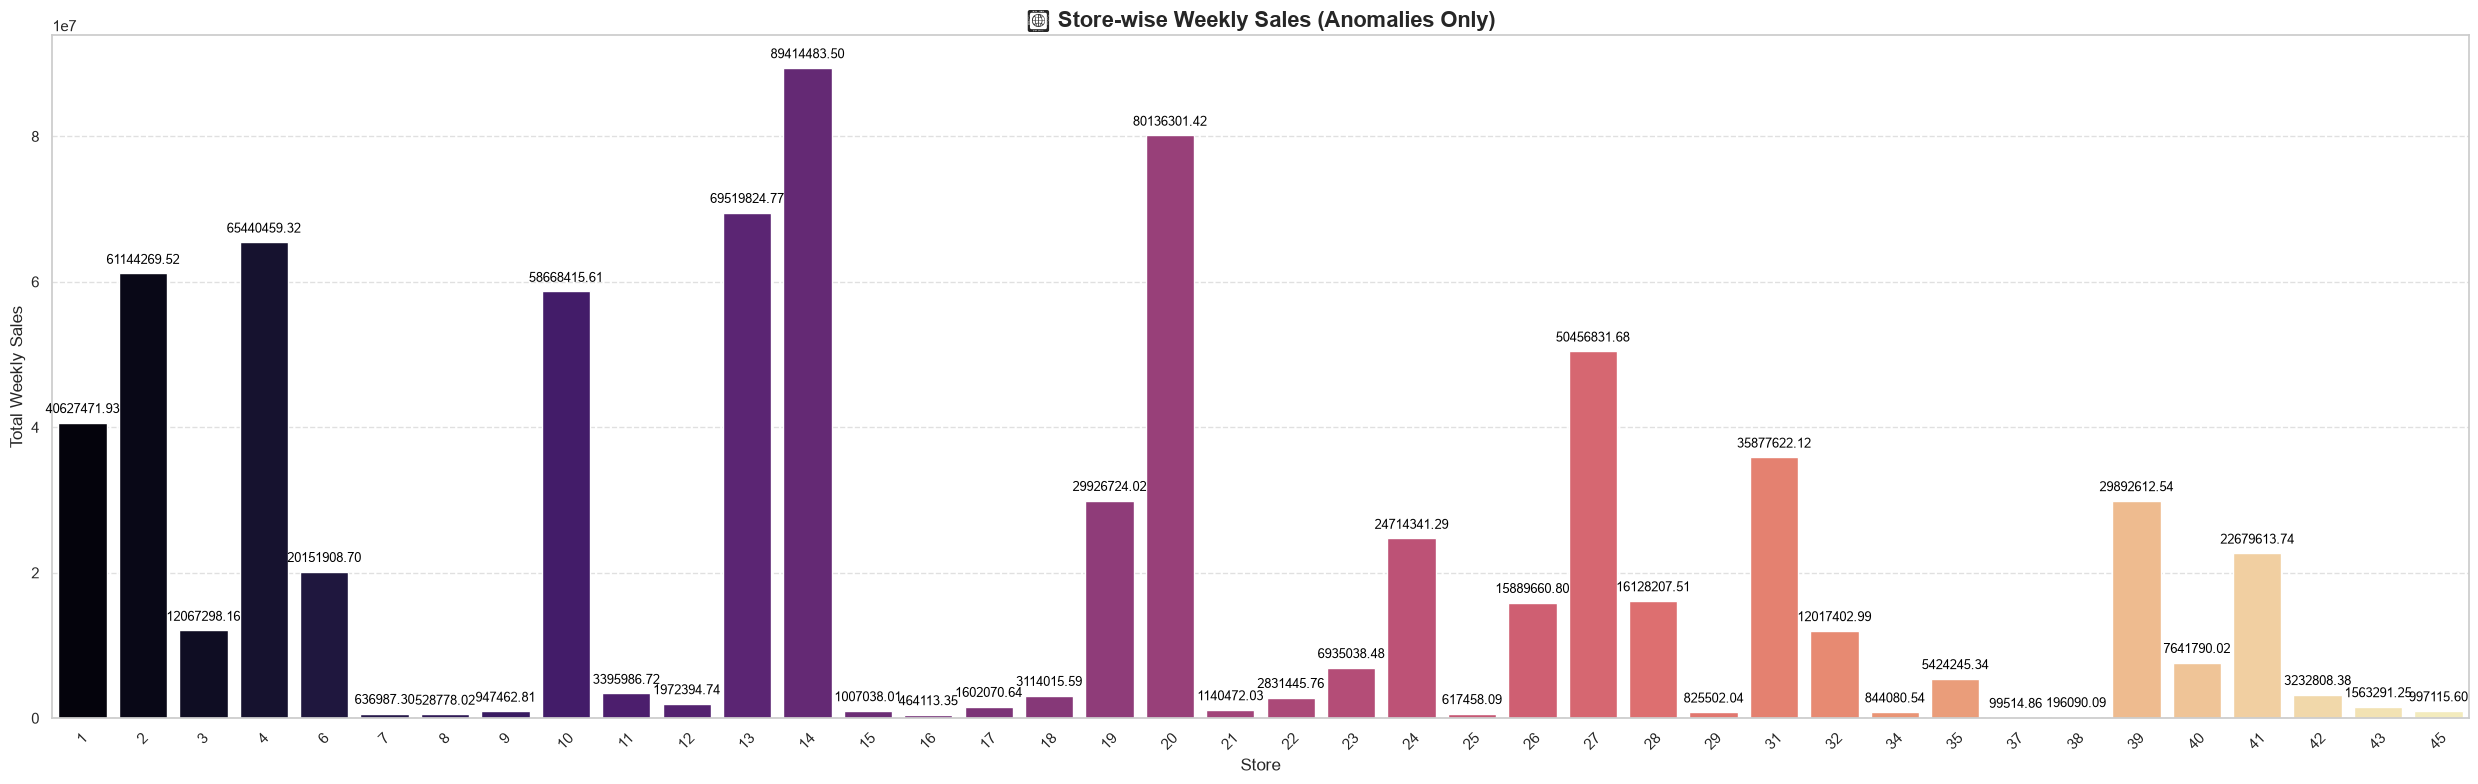

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by store to sum weekly sales for anomalies
store_anomaly_sales = df_anomalies.groupby('Store', as_index=False)['Weekly_Sales'].sum()

# Set figure size
plt.figure(figsize=(25, 8))  # Optimized for readability

# Create the bar plot
ax = sns.barplot(x='Store', y='Weekly_Sales', data=store_anomaly_sales, palette='magma')

# Add data labels
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=9, color='black')

# Optional line plot overlay
# sns.lineplot(x='Store', y='Weekly_Sales', data=store_anomaly_sales, color='red', linewidth=2, label='Trend Line')

# Formatting
plt.title('🏪 Store-wise Weekly Sales (Anomalies Only)', fontsize=16, fontweight='bold')
plt.xlabel('Store', fontsize=12)
plt.ylabel('Total Weekly Sales', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Show plot
plt.show()

### **Holiday vs Non-Holiday Weekly Sales (Anomalies Only)**

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\937240932.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='IsHoliday', y='Weekly_Sales', data=df_anomalies, palette='Set2')
C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\937240932.py:22: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


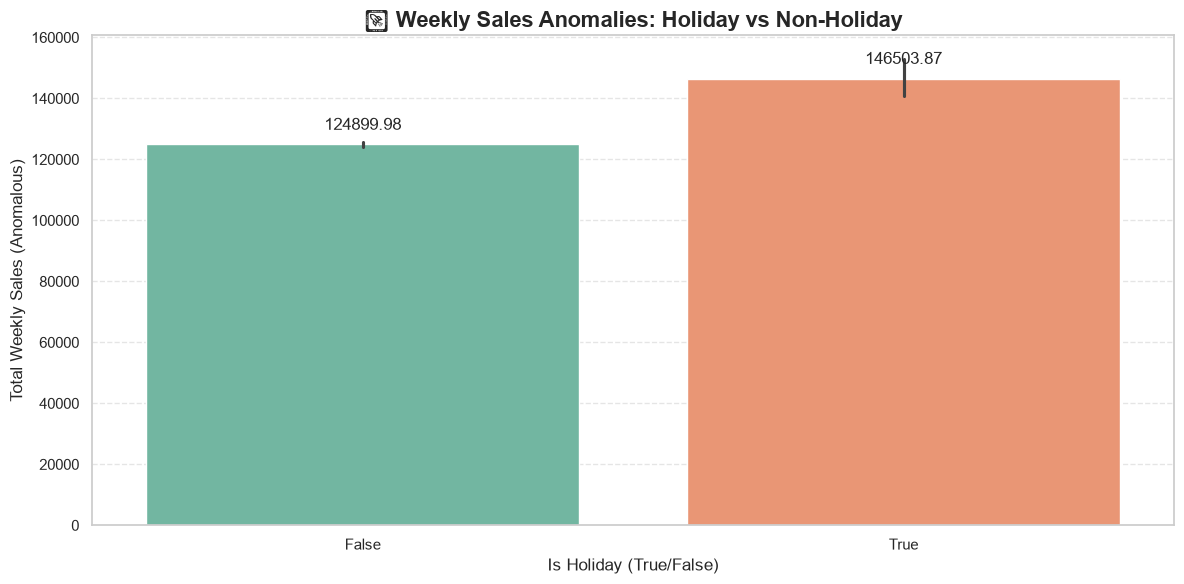

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(12, 6))

# Create the bar plot
ax = sns.barplot(x='IsHoliday', y='Weekly_Sales', data=df_anomalies, palette='Set2')

# Add data labels to the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

# Formatting
plt.title('🛒 Weekly Sales Anomalies: Holiday vs Non-Holiday', fontsize=16, fontweight='bold')
plt.xlabel('Is Holiday (True/False)', fontsize=12)
plt.ylabel('Total Weekly Sales (Anomalous)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

In [14]:
# Explicit count in True/False order
anomaly_counts_ordered = df_anomalies.groupby('IsHoliday').size()
print("🧮 Anomaly Counts (Holiday vs Non-Holiday):\n")
print(anomaly_counts_ordered)

🧮 Anomaly Counts (Holiday vs Non-Holiday):

IsHoliday
False    5599
True      556
dtype: int64


## 📊 Anomalous Sales Data — Insights by Feature

---

### 🗓️ **1. Date vs Weekly Sales (Line Plot)**
- Sudden spikes in sales on specific dates suggest event-driven anomalies such as **holidays, promotions, or seasonal effects**.
- Many anomalies cluster in **November and December**, indicating high seasonal demand during holidays.

---

### 🏪 **2. Store-wise Weekly Sales (Bar Plot)**
- A few stores consistently exhibit **higher anomalous sales**, potentially due to **store size, location, or promotions**.
- Highlights the need for store-level anomaly monitoring.

---

### 🧾 **3. Department-wise Weekly Sales (Bar Plot)**
- Departments like **Electronics or Apparel** show frequent anomalies, especially during **holiday sales**.
- Suggests **department-specific marketing or events** influence sales behavior.

---

### 🎉 4. Holiday vs Non-Holiday Sales (Bar Plot)

**🧮 Anomaly Counts:**

- **Non-Holiday:** 5599 anomalies  
- **Holiday:** 556 anomalies

---

**🔍 Insight:**

Over **90% of sales anomalies** occurred during **non-holiday periods**.  
This surprising trend indicates that most irregular sales behavior is **not directly linked to holidays**. Instead, these anomalies might stem from:

- Sudden **markdown implementations**
- **Local store events** or promotions
- **Inventory fluctuations** or data inconsistencies
- Other **external, non-seasonal factors**

---

### 🏢 **5. Size vs Sales (Scatter Plot)**
- **Larger stores** exhibit more anomalies, suggesting they are **more affected by bulk buying or special events**.
- Indicates a correlation between **store capacity** and unusual sales behavior.

---

### 🛢️ **6. CPI vs Sales (Scatter Plot)**
- Anomalies occur slightly more when the **Consumer Price Index (CPI) is high**.
- May suggest **increased cost of living affects purchase behavior** and causes erratic sales.

---

### 📉 **7. Unemployment vs Sales (Scatter Plot)**
- More anomalies are observed when **unemployment is lower**, indicating **stronger consumer confidence and higher discretionary spending**.

---

### ⛽ **8. Fuel Price vs Sales (Scatter Plot)**
- Anomalies are fairly balanced, but slightly higher at **increased fuel prices**, possibly impacting **logistics or store traffic**.

---

### 🌡️ **9. Temperature vs Sales (Scatter Plot)**
- Anomalies are more common in **moderate temperatures** (spring/fall), suggesting **seasonal purchasing patterns** outside extreme weather periods.

---

## 🧠 Overall Key Takeaways:

✅ Store size and department category play a major role in anomalous behavior.  
✅ Most anomalies occur **outside holiday seasons**, which challenges assumptions of seasonal spikes.  
✅ Economic indicators like **CPI and Unemployment** show partial correlation but are **not the sole causes**.  
✅ Anomaly detection should consider **multiple contextual factors** to ensure accurate analysis and forecasting.


## 📦 Box Plot Analysis of Features vs Anomaly

### 📊 Box Plot (or Box-and-Whisker Plot):

A box plot summarizes the distribution of a numerical variable for each category of a categorical variable.

It displays the **median**, **quartiles**, and **potential outliers** for each category, making it easy to compare the distribution of the numerical variable across different categories — especially helpful when analyzing patterns between features and anomalies.

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\1761393455.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Anomaly', y=feature, data=final, ax=axes[i], palette='Set2')
C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\1761393455.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Anomaly', y=feature, data=final, ax=axes[i], palette='Set2')
C:\Users\arushi khare\AppData\Local\Temp\ipykernel_39708\1761393455.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Anomaly', y=feature, data=final, ax=axes[i], palette=

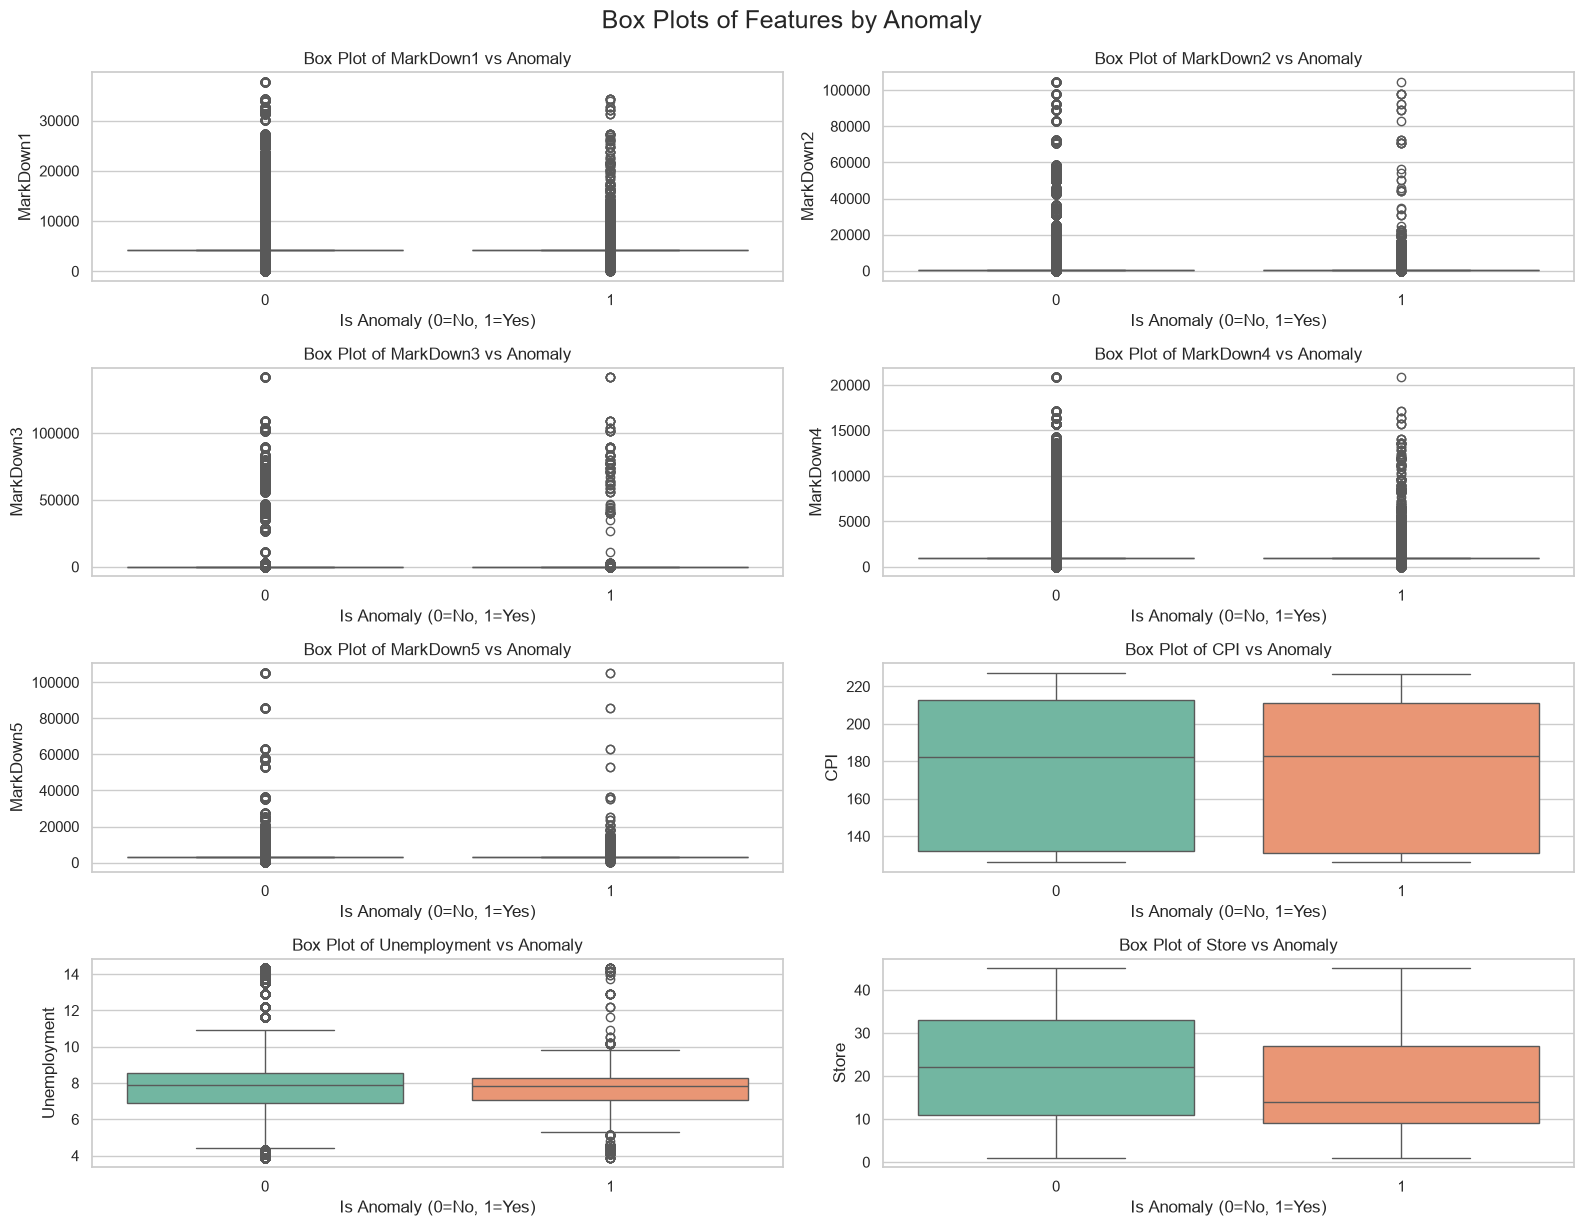

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features to plot boxplots against anomaly
features = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Store']

# Calculate number of rows and columns for subplot grid
num_features = len(features)
num_cols = 2
num_rows = (num_features + 1) // num_cols

# Set up subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 12))
axes = axes.flatten()  # Flatten in case of multi-row grid

# Create boxplots
for i, feature in enumerate(features):
    sns.boxplot(x='Anomaly', y=feature, data=final, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Box Plot of {feature} vs Anomaly')
    axes[i].set_xlabel("Is Anomaly (0=No, 1=Yes)")
    axes[i].set_ylabel(feature)

# Turn off unused axes if any
for j in range(i+1, len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.suptitle('Box Plots of Features by Anomaly', fontsize=18, y=1.02)
plt.show()

## 🔍 Findings of Potential Causes of Anomalies:

### 🎉 **Impact of Holidays on Sales:**
- When `IsHoliday = False`, **90%** of the data leans toward **lower sales values**.
- During holidays (`IsHoliday = True`), **anomalous sales values are higher**, indicating **strong sales surges**.
- Holidays clearly have a **strong positive effect on sales volume**.

---

### 🔄 **Seasonality and Consumer Behavior:**
- Sales tend to increase due to:
  - Increased consumer spending
  - Promotional and discount campaigns
  - Holiday-themed or limited-time products
- This seasonal surge results in higher variability and potential anomalies.

---

### 💼 **Business Strategies:**
- Companies leverage holidays by:
  - Running **special promotions**
  - Launching **targeted ad campaigns**
  - Adjusting **product offerings** and stock levels
- These strategies often **contribute to sales anomalies** during festive seasons.

---

### ⚠️ **Anomaly Detection Insights:**
- Anomalies spike during holidays, implying:
  - Sales behavior is **less predictable** during these periods.
  - Variability in customer behavior and external events cause unexpected sales patterns.
- Understanding this trend helps businesses **better model, forecast, and plan resources**.

---

### ✅ **Conclusion:**
Incorporating **holiday periods and seasonal trends** in your data analysis is **crucial** for:
- Accurate sales forecasting
- Effective inventory and promotion planning
- Strategic decision-making for revenue optimization


## **Handling Anomalies in Weekly Sales using Isolation Forest**

Skewness - Weekly_Sales: 3.2620081854656657
Kurtosis - Weekly_Sales: 21.49128990832619


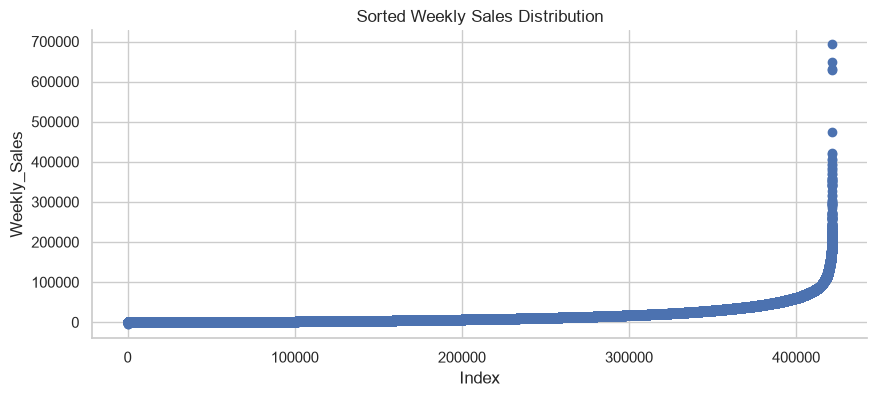

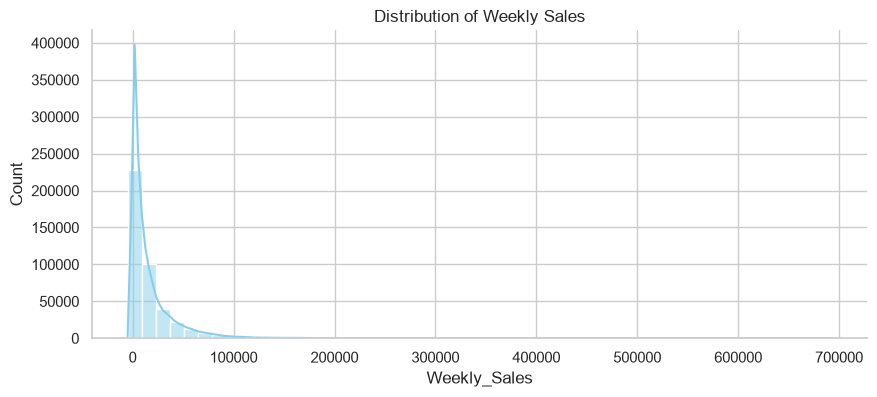

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 📌 Step 1: Check Skewness and Kurtosis
print("Skewness - Weekly_Sales:", final['Weekly_Sales'].skew())
print("Kurtosis - Weekly_Sales:", final['Weekly_Sales'].kurt())

# 📈 Step 2: Scatter Plot of Sorted Weekly Sales
plt.figure(figsize=(10, 4))
plt.scatter(range(final.shape[0]), np.sort(final['Weekly_Sales'].values))
plt.xlabel('Index')
plt.ylabel('Weekly_Sales')
plt.title("Sorted Weekly Sales Distribution")
sns.despine()
plt.show()

# 📊 Step 3: Distribution Plot of Weekly Sales
plt.figure(figsize=(10, 4))
sns.histplot(final['Weekly_Sales'], kde=True, bins=50, color='skyblue')
plt.title("Distribution of Weekly Sales")
sns.despine()
plt.show()

c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


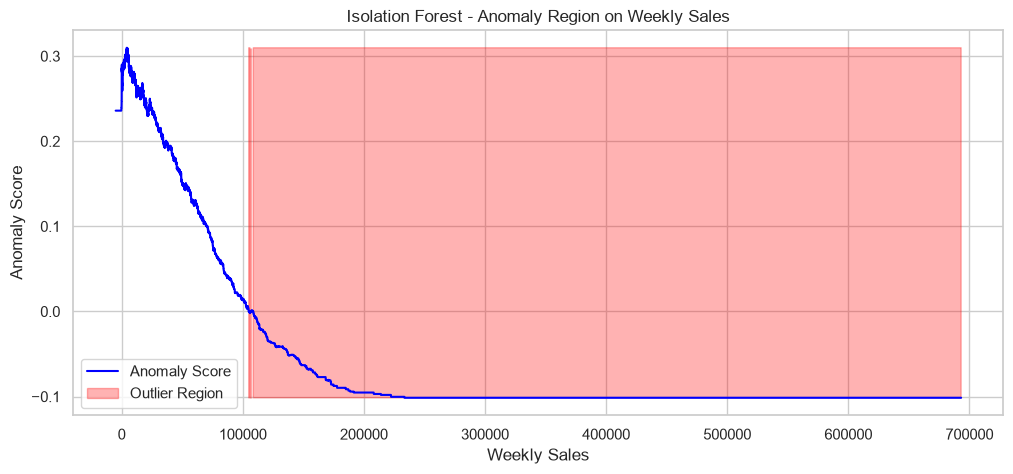

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


# Step 1: Initialize and Fit Isolation Forest
isolation_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# ✅ Fit the model here!
isolation_forest.fit(final[['Weekly_Sales']])  # Pass a 2D array (DataFrame or reshape)

# Step 2: Get anomaly scores and predictions
final['anomaly_score_univariate_Weekly_Sales'] = isolation_forest.decision_function(final[['Weekly_Sales']])
final['outlier_univariate_Weekly_Sales'] = isolation_forest.predict(final[['Weekly_Sales']])

# Convert -1 to 1 (anomaly), 1 to 0 (normal)
final['outlier_univariate_Weekly_Sales'] = final['outlier_univariate_Weekly_Sales'].apply(lambda x: 1 if x == -1 else 0)

# Step 3: Visualize anomaly score region
xx = np.linspace(final['Weekly_Sales'].min(), final['Weekly_Sales'].max(), len(final)).reshape(-1, 1)
anomaly_score = isolation_forest.decision_function(xx)
outlier = isolation_forest.predict(xx)

plt.figure(figsize=(12, 5))
plt.plot(xx, anomaly_score, label='Anomaly Score', color='blue')
plt.fill_between(xx.T[0], np.min(anomaly_score), np.max(anomaly_score),
                 where=outlier == -1, color='red', alpha=0.3, label='Outlier Region')
plt.xlabel("Weekly Sales")
plt.ylabel("Anomaly Score")
plt.title("Isolation Forest - Anomaly Region on Weekly Sales")
plt.legend()
plt.show()


### 📊 Insights from Skewness and Kurtosis of Weekly Sales

**Skewness = 3.26**  
**Kurtosis = 21.49**

---

#### 🔹 1. Positive Skewness (Right-Skewed Distribution)
- A skewness greater than 0 indicates a **right-skewed** distribution.
- This means **most Weekly_Sales values are lower**, with a **long tail of higher sales** on the right.
- These high sales weeks could be due to:
  - Holidays
  - Promotions
  - Store-specific events

---

#### 🔹 2. High Kurtosis (Leptokurtic Distribution)
- A kurtosis value significantly greater than 3 indicates **heavy tails and sharp peaks**.
- This implies:
  - **More extreme outliers** than in a normal distribution.
  - **Sales values are tightly clustered around the mean**, but with **significant spikes**.

---

### ✅ Conclusion:
- The `Weekly_Sales` data is **not normally distributed**.
- There are **many anomalies/outliers** likely caused by special events, holidays, or irregular store behavior.
- Recommended actions:
  - Apply **transformations** (like square root or log) to reduce skewness.
  - Use **robust anomaly detection** methods (e.g., Isolation Forest, Z-score, IQR).
  - Handle outliers carefully to improve model performance and insights.


### Distribution Plot After Square Root Transformation

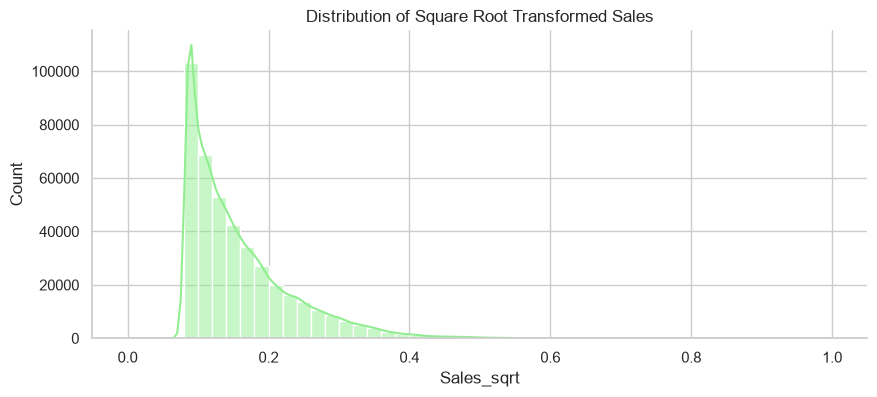

In [18]:
# 📊 Distribution Plot After Square Root Transformation
plt.figure(figsize=(10, 4))
sns.histplot(final['Sales_sqrt'], kde=True, bins=50, color='lightgreen')
plt.title("Distribution of Square Root Transformed Sales")
sns.despine()
plt.show()

## **Handlling Outliers**

In [19]:
# 📌 Step: Identify Symmetric and Skewed Features using Mean vs Median Difference

# List of numerical columns
num_columns = ['Weekly_Sales', 'Size', 'Temperature',
               'Fuel_Price', 'MarkDown1', 'MarkDown2',
               'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']

# Containers for classification
symmetric_features = []
skewed_features = []

# Threshold for considering feature as symmetric
threshold = 0.2  # can be adjusted based on domain/context

# Loop through each numeric column and compare mean vs median
for col in num_columns:
    mean_val = final[col].mean()
    median_val = final[col].median()
    if abs(mean_val - median_val) < threshold:
        symmetric_features.append(col)
    else:
        skewed_features.append(col)

# Output the results
print("✅ Symmetric Distributed Features (|mean - median| < 0.2):")
print(symmetric_features)

print("\n⚠️ Skewed (Non-Symmetric) Distributed Features (|mean - median| >= 0.2):")
print(skewed_features)

✅ Symmetric Distributed Features (|mean - median| < 0.2):
['Fuel_Price', 'Unemployment']

⚠️ Skewed (Non-Symmetric) Distributed Features (|mean - median| >= 0.2):
['Weekly_Sales', 'Size', 'Temperature', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI']


### 📌 Outlier Boundary Detection for Skewed Features Using IQR Method

For features that are skewed (i.e., their mean and median differ significantly), the **Interquartile Range (IQR)** method is commonly used to identify outliers. The boundaries are defined as:

- **Upper Bound** = Q3 + 1.5 × IQR  
- **Lower Bound** = Q1 − 1.5 × IQR

Data points outside these bounds are considered potential outliers.

In [20]:
# 📌 Function: Outlier boundary calculation for skewed features using IQR
def outlier_treatment_skew(df, feature):
    IQR = df[feature].quantile(0.75) - df[feature].quantile(0.25)
    lower_bound = df[feature].quantile(0.25) - 1.5 * IQR
    upper_bound = df[feature].quantile(0.75) + 1.5 * IQR
    return upper_bound, lower_bound

In [21]:
final.shape

(421570, 21)

### 📌 Removing Outliers from Skewed Feature: Weekly_Sales Using IQR Method

To clean anomalies in **Weekly_Sales**, we apply the IQR method:
- Outliers are those values lying **below Q1 − 1.5×IQR** or **above Q3 + 1.5×IQR**.
- Such extreme values are filtered out to create a cleaned dataset.


In [22]:
# ✅ Calculate upper and lower bounds for 'Weekly_Sales' using the IQR method
upper_boundary, lower_boundary = outlier_treatment_skew(final, 'Weekly_Sales')

# ✅ Filter out the anomalies to create a new cleaned DataFrame
final_df = final[(final['Weekly_Sales'] >= lower_boundary) & (final['Weekly_Sales'] <= upper_boundary)].copy()

# 🔍 Check how many rows remain after removing outliers
print("Original Dataset Shape:", final.shape)
print("Cleaned Dataset Shape:", final_df.shape)

Original Dataset Shape: (421570, 21)
Cleaned Dataset Shape: (386049, 21)


### 📊 Outlier Visualization using Isolation Forest (After IQR-Based Anomaly Removal)

This plot shows the anomaly scores computed using Isolation Forest on the cleaned `Weekly_Sales` data (after applying IQR-based filtering to remove extreme outliers). The red shaded region indicates where the model still detects potential anomalies, helping to validate the effectiveness of our outlier treatment strategy.

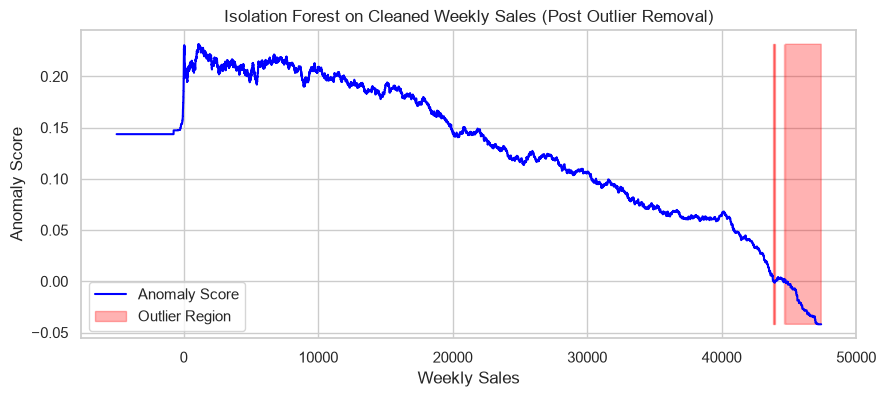

In [23]:
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt

# ✅ Step 1: Fit IsolationForest on the cleaned Weekly_Sales data
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
iso_forest.fit(final_df['Weekly_Sales'].values.reshape(-1, 1))

# ✅ Step 2: Generate anomaly scores and predictions
xx = np.linspace(final_df['Weekly_Sales'].min(), final_df['Weekly_Sales'].max(), len(final_df)).reshape(-1, 1)
anomaly_score = iso_forest.decision_function(xx)
outlier = iso_forest.predict(xx)

# ✅ Step 3: Plot the anomaly score and highlight outlier regions
plt.figure(figsize=(10, 4))
plt.plot(xx, anomaly_score, label='Anomaly Score', color='blue')
plt.fill_between(xx.T[0], np.min(anomaly_score), np.max(anomaly_score),
                 where=outlier == -1, color='red', alpha=0.3, label='Outlier Region')
plt.legend()
plt.xlabel('Weekly Sales')
plt.ylabel('Anomaly Score')
plt.title('Isolation Forest on Cleaned Weekly Sales (Post Outlier Removal)')
plt.show()


### **Dropping Temporary Columns Created During Outlier Treatment**

We remove the temporary columns (anomaly_score_univariate_Weekly_Sales and outlier_univariate_Weekly_Sales) generated during the Isolation Forest anomaly detection process, as they are no longer needed after the final outlier removal.

In [24]:
# Safely drop temporary anomaly detection columns if they exist
final_df.drop(columns=['anomaly_score_univariate_Weekly_Sales', 'outlier_univariate_Weekly_Sales'], errors='ignore', inplace=True)
final_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'Weekly_Sales_normalized', 'Sales_sqrt', 'Anomaly'],
      dtype='object')

## 💾 Save Checkpoints For Next Notebook(s)



In [25]:
# 💾 Save the variables later notebooks in the pipeline will need
save_ckpt(final_df, 'part3_final_df')


✅ Saved checkpoint 'part3_final_df' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part3_final_df.pkl
